# INDIA MARKET OPPORTUNITY ENGINE (ML — HIGH-GROWTH MARKET PREDICTION)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


MASTER_FILE = "data/processed/engine_master_data.csv"
LATEST_FILE = "data/processed/engine_latest_data.csv"

In [26]:

df = pd.read_csv(MASTER_FILE)
latest = pd.read_csv(LATEST_FILE)

print("=" * 70)
print("INDIA MARKET OPPORTUNITY ENGINE — ML MODULE")
print("=" * 70)

print("\nMaster shape :", df.shape)
print("Latest shape :", latest.shape)

# Clean columns

df.columns = df.columns.str.strip()
latest.columns = latest.columns.str.strip()

df["state"] = df["state"].astype(str).str.strip()
df["industry"] = df["industry"].astype(str).str.strip()

latest["state"] = latest["state"].astype(str).str.strip()
latest["industry"] = latest["industry"].astype(str).str.strip()


# 2. SORT PANEL DATA

df = df.sort_values(
    ["state", "industry", "year"]
).reset_index(drop=True)

INDIA MARKET OPPORTUNITY ENGINE — ML MODULE

Master shape : (8756, 17)
Latest shape : (656, 17)


In [27]:
# ============================================================
# 3. CREATE NEXT-YEAR STARTUP GROWTH
# ============================================================
#
# For each State × Industry:
#
# Current year:
#       t
#
# Target:
#       startup growth from t → t+1
#
# This is critical because we want to predict FUTURE growth.
# ============================================================

df["next_year_startups"] = (
    df.groupby(
        ["state", "industry"]
    )["industry_startups"]
    .shift(-1)
)


df["next_year_startup_growth"] = np.where(
    df["industry_startups"] > 0,

    (
        (
            df["next_year_startups"]
            - df["industry_startups"]
        )
        /
        df["industry_startups"]
    ) * 100,

    np.nan
)

In [28]:

# ============================================================
# 4. CREATE HIGH-GROWTH TARGET
# ============================================================
#
# A market is considered "High Growth" if its next-year
# startup growth is in the TOP 25% within that industry-year.
#
# This is much better than using an arbitrary number such as
# 20% growth because startup growth varies heavily by industry.
# ============================================================

df["growth_percentile"] = (
    df
    .groupby(["year", "industry"])
    ["next_year_startup_growth"]
    .rank(
        pct=True,
        method="average"
    )
)


df["high_growth"] = np.where(
    df["growth_percentile"] >= 0.75,
    1,
    0
)

In [29]:
# ============================================================
# 5. ML FEATURES
# ============================================================
#
# ONLY CURRENT-YEAR INFORMATION.
#
# We deliberately DO NOT use:
#
# - next_year_startups
# - next_year_startup_growth
# - growth_percentile
# - high_growth
# - opportunity scores
#
# because they contain future information or are downstream
# outputs of the Opportunity Engine.
# ============================================================

feature_columns = [

    "industry_startups",

    "industry_share",

    "industry_cagr_3y",

    "startup_cagr_3y",

    "startup_nsva_ratio",

    "nsva_growth",

    "industry_hhi",

    "underpenetration_score"
]


# Check features
missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

if missing_features:

    raise ValueError(
        f"Missing ML features: {missing_features}"
    )

In [30]:
# 6. REMOVE INVALID OBSERVATIONS

model_data = df[
    feature_columns
    + [
        "year",
        "state",
        "industry",
        "next_year_startup_growth",
        "high_growth"
    ]
].copy()


model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)


model_data = model_data.dropna(
    subset=feature_columns
    + ["next_year_startup_growth"]
)


print("\nML dataset shape:", model_data.shape)


ML dataset shape: (3647, 13)


In [31]:
# 7. CHECK TARGET BALANCE

print("\nTarget distribution:")

print(
    model_data["high_growth"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentage:")

print(
    model_data["high_growth"]
    .value_counts(
        normalize=True
    )
    .sort_index()
)


Target distribution:
high_growth
0    2626
1    1021
Name: count, dtype: int64

Target percentage:
high_growth
0    0.720044
1    0.279956
Name: proportion, dtype: float64


In [32]:
# ============================================================
# 8. TEMPORAL TRAIN / TEST SPLIT
# ============================================================
#
# IMPORTANT:
#
# We DO NOT randomly split the data.
#
# This is a forecasting problem.
#
# Earlier years → training
# Most recent historical year → testing
#
# This prevents future information leaking backwards.
# ============================================================

available_target_years = sorted(
    model_data["year"].unique()
)

test_year = available_target_years[-1]

train_years = [
    y
    for y in available_target_years
    if y < test_year
]


train = model_data[
    model_data["year"].isin(train_years)
].copy()


test = model_data[
    model_data["year"] == test_year
].copy()


print("\nTraining years:")
print(
    min(train_years),
    "→",
    max(train_years)
)

print("\nTest year:")
print(test_year)

print("\nTrain shape:", train.shape)
print("Test shape :", test.shape)


# 9. X / y

X_train = train[feature_columns]
y_train = train["high_growth"]

X_test = test[feature_columns]
y_test = test["high_growth"]


Training years:
2020 → 2023

Test year:
2024

Train shape: (3052, 13)
Test shape : (595, 13)


In [33]:
# ============================================================
# 10. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=8,

    min_samples_leaf=5,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)


rf.fit(
    X_train,
    y_train
)


# 11. TEST PREDICTIONS

y_pred = rf.predict(
    X_test
)

y_prob = rf.predict_proba(
    X_test
)[:, 1]


# 12. MODEL PERFORMANCE

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"\nRandom Forest"
)

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1 Score  : {f1:.3f}"
)


MODEL PERFORMANCE

Random Forest
Accuracy  : 0.667
Precision : 0.449
Recall    : 0.500
F1 Score  : 0.473


In [34]:
if y_test.nunique() == 2:

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    print(
        f"ROC-AUC   : {auc:.3f}"
    )

else:

    auc = np.nan

    print(
        "ROC-AUC   : Not available "
        "(test set contains one class)"
    )


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

ROC-AUC   : 0.686

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       417
           1       0.45      0.50      0.47       178

    accuracy                           0.67       595
   macro avg       0.61      0.62      0.62       595
weighted avg       0.68      0.67      0.67       595



In [35]:
# 13. CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# 14. FEATURE IMPORTANCE

importance = pd.DataFrame({

    "feature": feature_columns,

    "importance": rf.feature_importances_

})


importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance.to_string(
        index=False
    )
)


Confusion Matrix:
[[308 109]
 [ 89  89]]

FEATURE IMPORTANCE
               feature  importance
      industry_cagr_3y    0.224546
     industry_startups    0.203268
        industry_share    0.131768
underpenetration_score    0.117138
    startup_nsva_ratio    0.104626
           nsva_growth    0.077668
       startup_cagr_3y    0.074568
          industry_hhi    0.066416


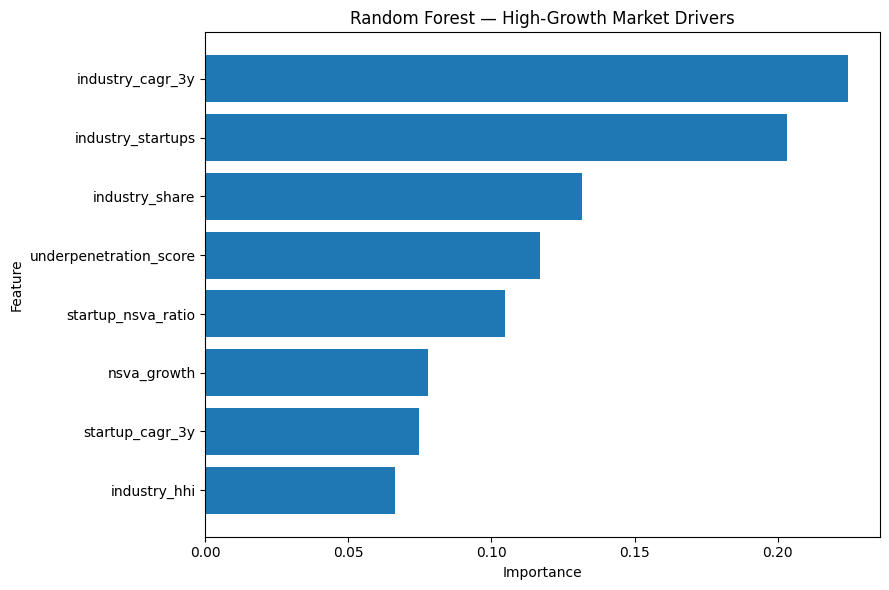

In [36]:
# 15. FEATURE IMPORTANCE PLOT

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest — High-Growth Market Drivers"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [37]:
# 16. TEST SET PREDICTIONS

test_results = test[
    [
        "year",
        "state",
        "industry",
        "next_year_startup_growth",
        "high_growth"
    ]
].copy()


test_results["predicted_high_growth"] = y_pred

test_results["growth_probability"] = (
    y_prob * 100
).round(2)


test_results = test_results.sort_values(
    "growth_probability",
    ascending=False
)


print("\n" + "=" * 70)
print("TEST-YEAR HIGH-GROWTH PREDICTIONS")
print("=" * 70)

print(
    test_results.head(20).to_string(
        index=False
    )
)


TEST-YEAR HIGH-GROWTH PREDICTIONS
 year          state                industry  next_year_startup_growth  high_growth  predicted_high_growth  growth_probability
 2024 Andhra Pradesh               Logistics                350.000000            1                      1               92.88
 2024          Bihar                  Safety                300.000000            1                      1               91.94
 2024          Bihar      Internet of Things                400.000000            1                      1               91.94
 2024 Madhya Pradesh               Analytics                 50.000000            1                      1               90.80
 2024      Rajasthan         Computer Vision                 50.000000            1                      1               89.84
 2024 Andhra Pradesh                Robotics                300.000000            1                      1               88.49
 2024 Madhya Pradesh                Robotics                  0.000000      

In [38]:
# ============================================================
# 17. TRAIN FINAL MODEL ON ALL HISTORICAL DATA
# ============================================================
#
# Once we have evaluated the model, we use ALL historical
# observations for the final model.
#
# Then we predict the latest year.
# ============================================================

X_all = model_data[
    feature_columns
]

y_all = model_data[
    "high_growth"
]


final_rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=8,

    min_samples_leaf=5,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)


final_rf.fit(
    X_all,
    y_all
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [39]:
# 18. PREPARE LATEST DATA

latest_ml = latest.copy()

latest_ml = latest_ml.replace(
    [np.inf, -np.inf],
    np.nan
)


latest_ml = latest_ml.dropna(
    subset=feature_columns
)


# 19. PREDICT NEXT-YEAR HIGH-GROWTH PROBABILITY

X_latest = latest_ml[
    feature_columns
]


latest_ml["ml_growth_probability"] = (

    final_rf
    .predict_proba(X_latest)[:, 1]

    * 100

)


latest_ml["ml_growth_probability"] = (
    latest_ml["ml_growth_probability"]
    .round(2)
)


latest_ml["ml_high_growth_prediction"] = (
    latest_ml["ml_growth_probability"]
    >= 50
).astype(int)

In [40]:
# 20. CREATE GROWTH POTENTIAL CATEGORY

def growth_category(prob):

    if prob >= 75:
        return "Very High"

    elif prob >= 60:
        return "High"

    elif prob >= 40:
        return "Moderate"

    else:
        return "Low"


latest_ml["ml_growth_category"] = (
    latest_ml["ml_growth_probability"]
    .apply(growth_category)
)

In [41]:
# 21. SAVE ML OUTPUT

ml_output_columns = [

    "year",
    "state",
    "industry",

    "industry_startups",

    "industry_share",

    "industry_cagr_3y",

    "startup_cagr_3y",

    "startup_nsva_ratio",

    "nsva_growth",

    "industry_hhi",

    "underpenetration_score",

    "ml_growth_probability",

    "ml_high_growth_prediction",

    "ml_growth_category"
]


ml_predictions = latest_ml[
    [
        col
        for col in ml_output_columns
        if col in latest_ml.columns
    ]
].copy()


ml_predictions = ml_predictions.sort_values(
    "ml_growth_probability",
    ascending=False
)


ml_predictions.to_csv(
    "data/ML/ml_growth_predictions.csv",
    index=False
)

In [42]:
# 22. DISPLAY TOP PREDICTED MARKETS

print("\n" + "=" * 70)
print("LATEST-YEAR ML GROWTH POTENTIAL")
print("=" * 70)

print(
    ml_predictions[
        [
            "state",
            "industry",
            "ml_growth_probability",
            "ml_growth_category"
        ]
    ]
    .head(25)
    .to_string(index=False)
)


LATEST-YEAR ML GROWTH POTENTIAL
         state                            industry  ml_growth_probability ml_growth_category
Andhra Pradesh                           Animation                  89.53          Very High
Andhra Pradesh                              Sports                  89.53          Very High
Andhra Pradesh                      Social Network                  89.53          Very High
Andhra Pradesh                              Design                  84.94          Very High
Andhra Pradesh                  Internet of Things                  81.29          Very High
Andhra Pradesh               Non- Renewable Energy                  80.18          Very High
Andhra Pradesh                     Computer Vision                  79.42          Very High
   Uttarakhand            Transportation & Storage                  79.41          Very High
   Uttarakhand      Telecommunication & Networking                  79.41          Very High
   Uttarakhand                      S

In [43]:
# ============================================================
# 23. COMBINE ML WITH OPPORTUNITY ENGINE
# ============================================================
#
# This creates the final decision-support dataset.
#
# IMPORTANT:
#
# ML probability does NOT change the Opportunity Score.
#
# It is an independent predictive signal.
# ============================================================

try:

    opportunity = pd.read_csv(
        "data/processed/opportunity_engine_final.csv"
    )

    opportunity["state"] = (
        opportunity["state"]
        .astype(str)
        .str.strip()
    )

    opportunity["industry"] = (
        opportunity["industry"]
        .astype(str)
        .str.strip()
    )

    ml_predictions["state"] = (
        ml_predictions["state"]
        .astype(str)
        .str.strip()
    )

    ml_predictions["industry"] = (
        ml_predictions["industry"]
        .astype(str)
        .str.strip()
    )


    final_engine = opportunity.merge(

        ml_predictions[
            [
                "state",
                "industry",
                "ml_growth_probability",
                "ml_high_growth_prediction",
                "ml_growth_category"
            ]
        ],

        on=[
            "state",
            "industry"
        ],

        how="left"
    )


    final_engine.to_csv(
        "data/ML/india_market_opportunity_engine.csv",
        index=False
    )


    print("\n" + "=" * 70)
    print("FINAL ENGINE CREATED")
    print("=" * 70)

    print(
        "india_market_opportunity_engine.csv"
    )


except FileNotFoundError:

    print(
        "\nOpportunity engine file not found."
    )

    print(
        "ML predictions were still saved successfully."
    )


FINAL ENGINE CREATED
india_market_opportunity_engine.csv
